# REINFORCE: Monte-Carlo Control with Policy Approximation

## Installation and Setup

In [12]:
# uncomment if needed
# %pip install "gym-classics2 @ git+https://github.com/mhahsler/gym-classics2.git"

In [13]:
import numpy as np
np.set_printoptions(precision=2)

SEED = 42
rng = np.random.default_rng(SEED)

In [14]:
import gymnasium as gym
import gym_classics2
gym_classics2.register('gymnasium')

/home/mhahsler/miniconda3/envs/reinforcement-learning/lib/python3.12/site-packages/gym_classics2/__init__.py:89: UserWarning: gym-classics environments were already registered for gymnasium; additional calls to `register()` are ignored.
  warnings.warn("gym-classics environments were already registered for {}; "


## Define the L-Maze Grid World 

In [15]:
gym_env = gym.make('LMaze-v0', tabular = False)
env = gym_env.unwrapped
env.reset(seed=SEED)

((3, 2), {})

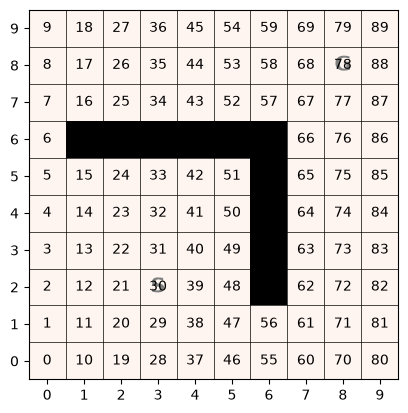

In [16]:
env.image()

## Policy Approximation: Linear Soft-Max In Action Preferences

Use Fourier-basis transformation and set up state-action features.

In [17]:
from gym_classics2.algorithms.linear_approximation import transformation_fourier_basis, state_action_features

trans_fb = transformation_fourier_basis(min = np.array([0,0]), max = env.dims, order=2)

def state_features(s,env):
    return trans_fb(s)


Define the preference function $h(s,a,\bf{\theta})=\bf{\theta}^\top \bf{x}(s,a)$

In [18]:
def h(s, a, theta, env, state_features):
    return np.dot(theta, state_action_features(s, a, env, state_features))

Soft-max transformation from scores to a probability distribution: $\pi(s,a,\theta) = \frac{e^{h(s,a,\bf{\theta})}}{\sum_b h(s,a,\bf{\theta})}$

In [19]:
def pi(s, theta, env, state_features):
    hs = np.array([h(s, a, theta, env, state_features) for a in range(env.action_space.n)])
    exp_hs = np.exp(hs)
    return exp_hs / np.sum(exp_hs)

Check with a random weight vector.

In [20]:
theta = rng.random(len(state_action_features((0, 0), 0, env, state_features)))
theta

array([0.77, 0.44, 0.86, 0.7 , 0.09, 0.98, 0.76, 0.79, 0.13, 0.45, 0.37,
       0.93, 0.64, 0.82, 0.44, 0.23, 0.55, 0.06, 0.83, 0.63, 0.76, 0.35,
       0.97, 0.89, 0.78, 0.19, 0.47, 0.04, 0.15, 0.68, 0.74, 0.97, 0.33,
       0.37, 0.47, 0.19, 0.13])

Calculate the preferences score for all actions for state 0.

In [21]:
[h((0, 0),a,theta, env, state_features) for a in range(env.action_space.n)] 

[np.float64(5.51391777674602),
 np.float64(5.213769440512151),
 np.float64(6.0518852267808905),
 np.float64(4.354555217712376)]

Calculate $\pi(s,a,\theta)$ for all actions in state $s=0$

In [22]:
pi((0, 0), theta, env, state_features)

array([0.27, 0.2 , 0.45, 0.08])

## REINFORCE: Monte-Carlo Control

![Pseudocode REINFORCE](https://raw.githubusercontent.com/mhahsler/Introduction_to_Reinforcement_Learning/refs/heads/main/figures/RL-Intro_REINFORCE.png)

We need to sample following a stochastic policy.

In [23]:
def sample_episode_policy(env, pi, theta, state_features, max_episode_length=1000, rng=None):
    """
    Sample an episode using the policy defined by pi and theta.
    Returns a list of (state, action, reward) tuples.
    """
    rng = np.random.default_rng(rng)
    s, _ = env.reset()
    episode_data = []
    
    for t in range(max_episode_length):
        a = rng.choice(env.action_space.n, p=pi(s, theta, env, state_features))
        next_s, r, done, _, _ = env.step(a)
        episode_data.append((s, a, r, next_s))
        s = next_s
        
        if done:
            break
    
    return episode_data


In [25]:
episode_data = sample_episode_policy(env, pi, theta, state_features, rng=rng)
episode_data

[((3, 2), 1, 0.0, (4, 2)),
 ((4, 2), 0, 0.0, (4, 3)),
 ((4, 3), 1, 0.0, (5, 3)),
 ((5, 3), 1, 0.0, (5, 3)),
 ((5, 3), 3, 0.0, (4, 3)),
 ((4, 3), 2, 0.0, (4, 2)),
 ((4, 2), 1, 0.0, (5, 2)),
 ((5, 2), 3, 0.0, (4, 2)),
 ((4, 2), 2, 0.0, (4, 1)),
 ((4, 1), 1, 0.0, (5, 1)),
 ((5, 1), 0, 0.0, (5, 2)),
 ((5, 2), 2, 0.0, (5, 1)),
 ((5, 1), 0, 0.0, (5, 2)),
 ((5, 2), 0, 0.0, (5, 3)),
 ((5, 3), 0, 0.0, (5, 4)),
 ((5, 4), 3, 0.0, (4, 4)),
 ((4, 4), 2, 0.0, (4, 3)),
 ((4, 3), 2, 0.0, (4, 2)),
 ((4, 2), 2, 0.0, (4, 1)),
 ((4, 1), 1, 0.0, (5, 1)),
 ((5, 1), 1, 0.0, (6, 1)),
 ((6, 1), 0, 0.0, (6, 1)),
 ((6, 1), 0, 0.0, (6, 1)),
 ((6, 1), 2, 0.0, (6, 0)),
 ((6, 0), 1, 0.0, (7, 0)),
 ((7, 0), 2, 0.0, (7, 0)),
 ((7, 0), 3, 0.0, (6, 0)),
 ((6, 0), 1, 0.0, (7, 0)),
 ((7, 0), 2, 0.0, (7, 0)),
 ((7, 0), 2, 0.0, (7, 0)),
 ((7, 0), 0, 0.0, (7, 1)),
 ((7, 1), 0, 0.0, (7, 2)),
 ((7, 2), 2, 0.0, (7, 1)),
 ((7, 1), 0, 0.0, (7, 2)),
 ((7, 2), 2, 0.0, (7, 1)),
 ((7, 1), 3, 0.0, (6, 1)),
 ((6, 1), 0, 0.0, (6, 1)),
 

Implement the REINFORCE algorithm. The gradient of the policy for linear approximation is proportional to  $\nabla ln\ \pi(s,a,\bf{\theta}) =   \bf{x}(s,a) - \sum_b \pi(b|s,\bf{\theta}) \bf{x}(s,b)$

In [26]:
from gym_classics2.algorithms.schedules import LinearDecaySchedule, ConstantSchedule
from tqdm import tqdm

def REINFORCE(
    env,
    state_features,
    n,
    alpha,
    gamma,
    theta = None,
    max_episode_length=1000,
    verbose=False,
    history=False,
    rng=None,
    ):
    rng = np.random.default_rng(rng)
    
    if theta is None:
        state, _ = env.reset()  
        theta = np.zeros(1 + len(state_features(state, env)) * env.action_space.n)
    
    if history:
        returns = []        
        ep_lens = []
        thetas = []
        thetas.append(theta.copy())
        
    for episode in tqdm(range(n), desc="Episodes", disable=verbose):
        if verbose:
            print(f"Episode {episode+1}/{n}")
        
        episode_data = sample_episode_policy(env, pi, theta, state_features, max_episode_length, rng=rng)
        
        for t in range(len(episode_data)):
            G = np.sum([e[2] for e in episode_data[t:]] * (gamma ** np.arange(len(episode_data[t:]))))
            if history and t == 0:
                returns.append(G)   

            s,a,r,next_s = episode_data[t]
            
            # ln policy gradient= x(s,a)- sum_b pi(b|s,theta) x(s,b)
            grad_log_pi = state_action_features(s, a, env, state_features) - sum([pi(s, theta, env, state_features)[b] * state_action_features(s, b, env, state_features) for b in range(env.action_space.n)])
            
            if verbose: 
                print (f"t: {t}, G: {G}, grad_log_pi: {grad_log_pi}")
            
            theta += alpha(episode) * (gamma**t) * G * grad_log_pi
            
        if history:
            thetas.append(theta.copy())
            ep_lens.append(len(episode_data))
            
    if history:
        return theta, {'thetas': thetas, 'returns': returns, 'ep_lens': ep_lens}
       
    return theta

In [27]:
theta, history = REINFORCE(env, state_features, n=2000, 
                           alpha=LinearDecaySchedule(0.1, 0.001, 1000),
                           gamma=0.99, 
                           max_episode_length = 500,
                           history=True,
                           rng=rng)

Episodes:   0%|          | 0/2000 [00:00<?, ?it/s]

Episodes: 100%|██████████| 2000/2000 [00:49<00:00, 40.23it/s] 


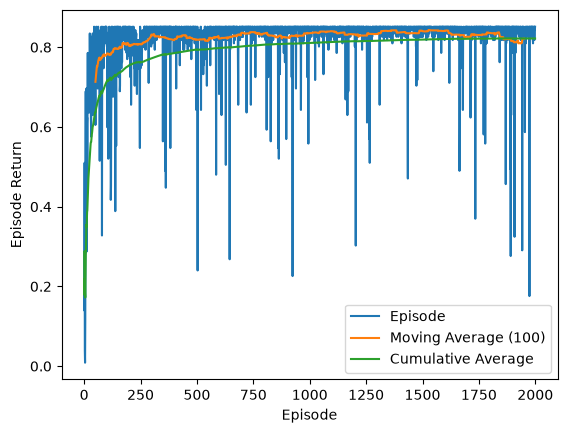

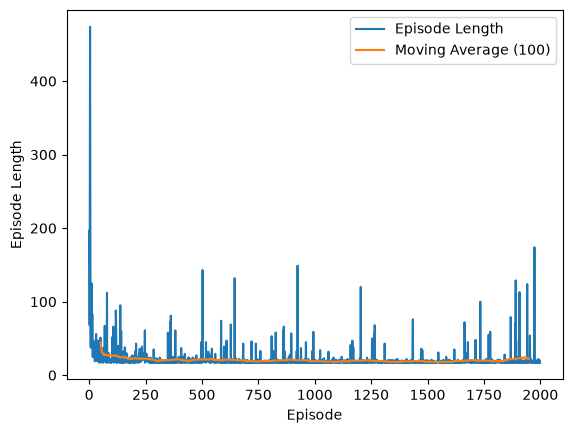

In [28]:
from gym_classics2.performance import plot_returns, plot_ep_lens
plot_returns(history['returns'])
plot_ep_lens(history['ep_lens'])

Note: MC produces initially high variance.

## The Learned Policy

In [29]:
pol = [pi(env.id2state(s), theta, env, state_features) for s in env.states()]
pol

[array([9.98e-01, 1.86e-03, 4.14e-04, 3.02e-07]),
 array([9.98e-01, 1.11e-03, 4.01e-04, 8.07e-07]),
 array([9.99e-01, 3.17e-04, 3.85e-04, 1.13e-05]),
 array([9.99e-01, 9.41e-05, 4.25e-04, 3.73e-04]),
 array([9.89e-01, 7.31e-05, 6.30e-04, 1.04e-02]),
 array([9.03e-01, 2.73e-04, 1.30e-03, 9.58e-02]),
 array([0.79, 0.01, 0.  , 0.2 ]),
 array([0.57, 0.33, 0.01, 0.09]),
 array([1.92e-02, 9.79e-01, 1.42e-03, 8.48e-04]),
 array([6.81e-04, 9.99e-01, 1.32e-04, 9.17e-06]),
 array([9.96e-01, 3.12e-03, 8.08e-04, 1.61e-06]),
 array([9.98e-01, 1.22e-03, 7.58e-04, 1.32e-05]),
 array([9.98e-01, 3.48e-04, 8.53e-04, 4.37e-04]),
 array([9.76e-01, 1.71e-04, 1.31e-03, 2.25e-02]),
 array([6.02e-01, 2.06e-04, 1.90e-03, 3.96e-01]),
 array([1.84e-01, 6.89e-04, 1.94e-03, 8.14e-01]),
 array([0.06, 0.86, 0.01, 0.08]),
 array([1.44e-03, 9.98e-01, 4.92e-04, 2.44e-04]),
 array([1.70e-04, 1.00e+00, 7.46e-05, 4.09e-06]),
 array([9.83e-01, 1.23e-02, 4.96e-03, 1.41e-04]),
 array([0.99, 0.  , 0.01, 0.  ]),
 array([0.86, 

Visualize the learned policy by showing the action with the highest probability. The probability is shown using the tile color. 
Closer to 1 means that the algorithm is more sure about the action. Smaller values means that the algorithms still would like to explore.

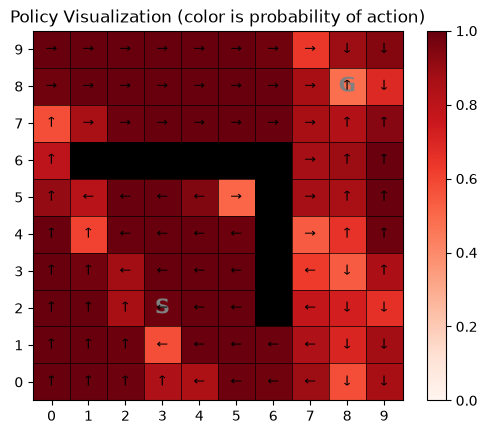

In [30]:
pol_discrete = np.argmax(pol, axis=1)
prob = np.max(pol, axis=1)
env.image(V=prob, policy=pol_discrete, title="Policy Visualization (color is probability of action)",  clim = (0,1))

Visualize the found path using the highest probability action.

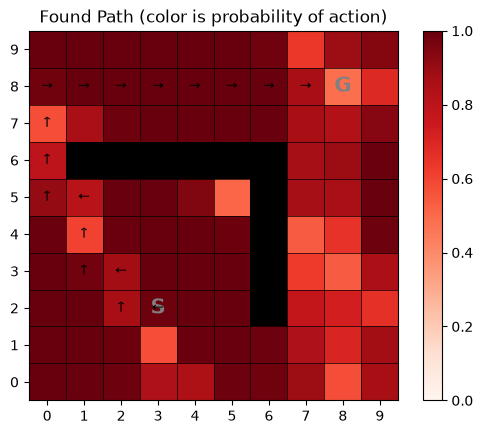

In [31]:
from gym_classics2.algorithms.monte_carlo_methods import sample_episode

path = sample_episode(env, policy=pol_discrete, max_len=100, rng=rng)
path = [(env.state2id(s), a, r,env.state2id(sp)) for s,a,r,sp in path]
env.image(V = prob, policy=pol_discrete, episode=path, title='Found Path (color is probability of action)', clim = (0,1))


&copy; 2025 [Michael Hahsler](https://michael.hahsler.net). 
This work is openly licensed under [Creative Commons Attribution-ShareAlike 4.0 International (CC BY-SA 4.0) License](https://creativecommons.org/licenses/by-sa/4.0/)

![CC BY-SA 4.0](https://licensebuttons.net/l/by-sa/3.0/88x31.png)